In [1]:
import numpy as np # used for array operations
import brian2 as b2 # used for neural simulation
from brian2 import NeuronGroup, Synapses, PoissonGroup, SpikeMonitor, run, ms, Hz
from scipy.stats import poisson, binom # used for stats (mean, s.d.)
import matplotlib.pyplot as plt # used for plotting
import json # to serialize
b2.prefs.codegen.target = "numpy" # set Brian2 to use numpy backend

In [2]:
# **Step 1: Generate Independent Poisson Processes**
def independent_poisson_processes(num_neurons, rate, time, num_samples):
    ind_processes = []
    spike_trains = []
    
    for _ in range(num_samples):
        sample_processes = []
        sample_spike_train = []
        for i in range(num_neurons):
            P = PoissonGroup(1, rate * b2.Hz)
            spike_monitor = SpikeMonitor(P)
            run(time * ms)
            spike_times = spike_monitor.spike_trains()[0]
            ind_process = np.zeros(int(time))  # Initialize with zeros
            for t in spike_times:
                if t < time * ms:
                    ind_process[int(t / ms)] = 1  # Convert t to unitless
            sample_processes.append(ind_process)
            sample_spike_train.append(spike_times)
    
        ind_processes.append(sample_processes)
        spike_trains.append(sample_spike_train)
    
    return ind_processes, spike_trains

In [3]:
# **Step 2: Generate Correlated Poisson Processes**
def correlated_poisson_processes(num_neurons, rate, time, num_common, num_samples):
    cor_processes = []
    for _ in range(num_samples):
        sample_processes = []
        independent_procs = []
        for i in range(num_neurons + num_common):
            # Using Brian2's PoissonGroup to generate a Poisson process
            P = b2.PoissonGroup(1, rate*b2.Hz)
            spike_monitor = b2.SpikeMonitor(P)
            b2.run(time * b2.ms)
            spike_times = spike_monitor.spike_trains()[0]
            # Convert spike times to a binary array
            cor_process = [0] * int(time)
            for t in spike_times:
                if t < time * b2.ms:  # Ensure units match
                    cor_process[int(t / b2.ms)] = 1  # Convert t to unitless
            independent_procs.append(cor_process)
        
        for i in range(num_neurons):
            if i < num_common:
                cor_process = [sum(x) for x in zip(*independent_procs[:i+1])]
            else:
                cor_process = independent_procs[i+num_common]
            sample_processes.append(cor_process)
        cor_processes.append(sample_processes)
    return cor_processes

In [4]:
def calculate_mean_and_variance(counting_process_nd_result):
    num_samples, num_neurons_to_plot, time = counting_process_nd_result.shape
    mean = np.mean(counting_process_nd_result, axis=0)
    variance = np.var(counting_process_nd_result, axis=0)
    return mean, variance

In [5]:
def counting_process_nd(independent_processes, num_samples, time, num_neurons_to_plot):
    counting_process_nd = np.zeros((num_samples, num_neurons_to_plot, time))
    for i in range(num_samples):
        counts = np.zeros(num_neurons_to_plot)
        for j in range(time):
            for k in range(num_neurons_to_plot):
                if independent_processes[i][k][j] == 1:
                    counts[k] += 1
            counting_process_nd[i, :, j] = counts
    return counting_process_nd

In [6]:
def plot_count_neuron1_vs_time(counting_process_nd, num_samples):
    plt.figure(figsize=(10,6))
    for i in range(num_samples):
        plt.plot(counting_process_nd[i][0], label=f'Sample {i}')
    mean_neuron1 = np.mean([counting_process_nd[i][0] for i in range(num_samples)], axis=0)
    plt.plot(mean_neuron1, label='Mean', color='black', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Count of Neuron 1')
    plt.title('Count of Neuron 1 Over Time')
    plt.ylim(0, None)  # Set y-axis lower limit to 0
    plt.show()

In [7]:
def plot_centered_staircase(counting_process_nd, num_samples, expected_mean):
    plt.figure(figsize=(10,6))
    for i in range(num_samples):
        plt.plot(counting_process_nd[i][0] - expected_mean, label=f'Sample {i}')
    mean_centered = np.mean([counting_process_nd[i][0] - expected_mean for i in range(num_samples)], axis=0)
    plt.plot(mean_centered, label='Mean', color='black', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Centered Count of Neuron 1')
    plt.title('Centered Count of Neuron 1 Over Time')
    plt.show()

In [8]:
def plot_standardized_staircase(counting_process_nd, num_samples, expected_mean):
    std_dev = np.std([counting_process_nd[i][0] for i in range(num_samples)], axis=0)
    plt.figure(figsize=(10,6))
    for i in range(num_samples):
        plt.plot((counting_process_nd[i][0] - expected_mean) / std_dev, label=f'Sample {i}')
    mean_standardized = np.mean([(counting_process_nd[i][0] - expected_mean) / std_dev for i in range(num_samples)], axis=0)
    plt.plot(mean_standardized, label='Mean', color='black', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Standardized Count of Neuron 1')
    plt.title('Standardized Count of Neuron 1 Over Time')
    plt.show()

In [9]:
def plot_centered_staircase_3d(counting_process_nd_result, num_samples, theoretical_means, theoretical_std_dev):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Iterate through the number of samples
    for i in range(num_samples):
        # Ensure that counting_process_nd_result[i] is structured correctly
        neuron1_data = counting_process_nd_result[i][0] - theoretical_means[0]
        neuron2_data = counting_process_nd_result[i][1] - theoretical_means[1]
        
        # Plot the data, by subtracting by the theoretical_means, i should be centering the data but it is not doing that ....
        ax.plot(range(len(neuron1_data)), neuron2_data, neuron1_data)

    # Calculate mean centered data for both neurons 
#    mean_centered_neuron1 = np.mean([(counting_process_nd_result[i][0] - theoretical_means[0]) / theoretical_std_dev[0] for i in range(num_samples)], axis=0)
#    mean_centered_neuron2 = np.mean([(counting_process_nd_result[i][1] - theoretical_means[1]) / theoretical_std_dev[1] for i in range(num_samples)], axis=0)

    # Plot mean centered data
#    ax.plot(range(len(mean_centered_neuron1)), mean_centered_neuron2, mean_centered_neuron1, color='black', linewidth=2)

    ax.set_xlabel('Time')
    ax.set_ylabel('Centered Count of Neuron 2')
    ax.set_zlabel('Centered Count of Neuron 1', rotation=90)
    ax.set_title('Centered Count of Neuron 1 vs Centered Count of Neuron 2 vs Time')

    ax.set_xlim(0, max(len(counting_process_nd_result[i][0]) for i in range(num_samples)))
#    max_val = max(max((counting_process_nd_result[i][1] - theoretical_means[1]) / theoretical_std_dev[1]) for i in range(num_samples))
#    ax.set_ylim(-max_val, max_val)
#    max_val = max(max((counting_process_nd_result[i][0] - theoretical_means[0]) / theoretical_std_dev[0]) for i in range(num_samples))
#    ax.set_zlim(-max_val, max_val)

    plt.show()


In [10]:
def plot_standardized_staircase_3d(counting_process_nd_result, num_samples, theoretical_means, theoretical_std_dev, t0):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Iterate through the number of samples
    for i in range(num_samples):
        # Ensure that counting_process_nd_result[i] is structured correctly
        neuron1_data = (counting_process_nd_result[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
        neuron2_data = (counting_process_nd_result[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
        
        # Plot the data, len(neuron1_data) should be = to len(neuron2_data) so either can be used
        ax.plot(range(t0,len(neuron1_data)), neuron2_data[t0:], neuron1_data[t0:])

    # Calculate mean standardized data for both neurons
#    mean_standardized_neuron1 = np.mean([counting_process_nd_result[i][0] / theoretical_std_dev[0] for i in range(num_samples)], axis=0)
#    mean_standardized_neuron2 = np.mean([counting_process_nd_result[i][1] / theoretical_std_dev[1] for i in range(num_samples)], axis=0)

    # Plot mean standardized data
#     ax.plot(range(len(mean_standardized_neuron1)), mean_standardized_neuron2, mean_standardized_neuron1, color='black', linewidth=2)

    ax.set_xlabel('Time')
    ax.set_ylabel('Standardized Count of Neuron 2')
    ax.set_zlabel('Standardized Count of Neuron 1', rotation=90)
    ax.set_title('Standardized Count of Neuron 1 vs Standardized Count of Neuron 2 vs Time')

#    ax.set_xlim(100, max(len(counting_process_nd_result[i][0]) for i in range(num_samples)))
#    ax.set_ylim(min(min(counting_process_nd_result[i][1] / theoretical_std_dev[1]) for i in range(num_samples)),
#                max(max(counting_process_nd_result[i][1] / theoretical_std_dev[1]) for i in range(num_samples)))
#    ax.set_zlim(min(min(counting_process_nd_result[i][0] / theoretical_std_dev[0]) for i in range(num_samples)),
#                max(max(counting_process_nd_result[i][0] / theoretical_std_dev[0]) for i in range(num_samples)))

    plt.show()


In [11]:
def plot_count_neuron1_vs_neuron2_vs_time(counting_process_nd, num_samples):
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_subplot(111, projection='3d')
    for i in range(num_samples):
        ax.plot(counting_process_nd[i][0], counting_process_nd[i][1], range(len(counting_process_nd[i][0])))
    mean_neuron1 = np.mean([counting_process_nd[i][0] for i in range(num_samples)], axis=0)
    mean_neuron2 = np.mean([counting_process_nd[i][1] for i in range(num_samples)], axis=0)
    ax.plot(mean_neuron1, mean_neuron2, range(len(mean_neuron1)), color='black', linewidth=2)
    ax.set_xlabel('Count of Neuron 1')
    ax.set_ylabel('Count of Neuron 2')
    ax.set_zlabel('Time', rotation=90)
    ax.set_title('Count of Neuron 1 vs Count of Neuron 2 vs Time')
    ax.set_xlim(0, max([max(counting_process_nd[i][0]) for i in range(num_samples)]))
    ax.set_ylim(0, max([max(counting_process_nd[i][1]) for i in range(num_samples)]))
    ax.set_zlim(0, max([len(counting_process_nd[i][0]) for i in range(num_samples)]))
    plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_centered_and_standardized_staircase_3d(counting_process_nd, num_samples, expected_mean):
    fig = plt.figure(figsize=(12,8))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    std_dev = np.std([counting_process_nd[i][0] for i in range(num_samples)], axis=0)

    for i in range(num_samples):
        ax1.plot(counting_process_nd[i][0] - expected_mean, counting_process_nd[i][1], range(len(counting_process_nd[i][0])))
        ax2.plot((counting_process_nd[i][0] - expected_mean) / std_dev, counting_process_nd[i][1], range(len(counting_process_nd[i][0])))

    mean_centered_neuron1 = np.mean([counting_process_nd[i][0] - expected_mean for i in range(num_samples)], axis=0)
    mean_neuron2 = np.mean([counting_process_nd[i][1] for i in range(num_samples)], axis=0)
    ax1.plot(mean_centered_neuron1, mean_neuron2, range(len(mean_centered_neuron1)), color='black', linewidth=2)

    mean_standardized_neuron1 = np.mean([(counting_process_nd[i][0] - expected_mean) / std_dev for i in range(num_samples)], axis=0)
    ax2.plot(mean_standardized_neuron1, mean_neuron2, range(len(mean_standardized_neuron1)), color='black', linewidth=2)

    # Calculate the covariance of the centered counts
    centered_counts_neuron1 = np.array([counting_process_nd[i][0] - expected_mean for i in range(num_samples)])
    centered_counts_neuron2 = np.array([counting_process_nd[i][1] for i in range(num_samples)])
    cov_centered = np.cov(centered_counts_neuron1, centered_counts_neuron2)

    # Calculate the covariance of the standardized counts
    standardized_counts_neuron1 = np.array([(counting_process_nd[i][0] - expected_mean) / std_dev for i in range(num_samples)])
    cov_standardized = np.cov(standardized_counts_neuron1, centered_counts_neuron2)

    print("Mean of centered counts of neuron 1:", mean_centered_neuron1)
    print("Mean of counts of neuron 2:", mean_neuron2)
    print("Covariance of centered counts:\n", cov_centered)
    print("Mean of standardized counts of neuron 1:", mean_standardized_neuron1)
    print("Covariance of standardized counts:\n", cov_standardized)

    ax1.set_xlabel('Centered Count of Neuron 1')
    ax1.set_ylabel('Count of Neuron 2')
    ax1.set_zlabel('Time', rotation=90)
    ax1.set_title('Centered Count of Neuron 1 vs Count of Neuron 2 vs Time')

    ax2.set_xlabel('Standardized Count of Neuron 1')
    ax2.set_ylabel('Count of Neuron 2')
    ax2.set_zlabel('Time', rotation=90)
    ax2.set_title('Standardized Count of Neuron 1 vs Count of Neuron 2 vs Time')

    plt.tight_layout()
    plt.show()


In [13]:
def calculate_theoretical_mean(rate, time):
    theoretical_mean = np.zeros((2, time))
    for i in range(time):
        theoretical_mean[0, i] = (rate * (i)) / 1000 
        theoretical_mean[1, i] = (rate * (i)) / 1000 
    return theoretical_mean

In [14]:
def calculate_theoretical_std_dev(theoretical_means):
    return np.sqrt(theoretical_means)

In [15]:
# Parameters
num_neurons = 3
rate = 10 # brian 2 units
t0 = 200
time = 1000
num_common = 2
num_samples = 100 #later set this to 10, then 100. 1 lets there be one replicate

In [16]:
theoretical_means = calculate_theoretical_mean(rate, time)
print(theoretical_means)
print(theoretical_means.shape)

[[0.   0.01 0.02 ... 9.97 9.98 9.99]
 [0.   0.01 0.02 ... 9.97 9.98 9.99]]
(2, 1000)


In [17]:
theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

[[0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]
 [0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]]
(2, 1000)


In [18]:
independent_processes, spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)

In [19]:
# mean, covariance, theoretical_mean = calculate_mean_and_covariance(independent_processes, num_samples, num_neurons, time)

In [20]:
counting_process_nd_result = counting_process_nd(independent_processes, num_samples, time, 2)

In [21]:
print(counting_process_nd_result)

[[[ 0.  0.  0. ...  7.  7.  7.]
  [ 0.  0.  0. ...  4.  4.  4.]]

 [[ 0.  0.  0. ... 13. 13. 13.]
  [ 0.  0.  0. ...  8.  8.  8.]]

 [[ 0.  0.  0. ...  8.  8.  8.]
  [ 0.  0.  0. ...  7.  7.  7.]]

 ...

 [[ 0.  0.  0. ... 13. 13. 13.]
  [ 0.  0.  0. ... 16. 16. 16.]]

 [[ 0.  0.  0. ... 12. 12. 12.]
  [ 0.  0.  0. ...  8.  8.  8.]]

 [[ 0.  0.  0. ...  8.  8.  8.]
  [ 0.  0.  0. ...  7.  7.  7.]]]


In [22]:
print(counting_process_nd_result[-1])

[[0. 0. 0. ... 8. 8. 8.]
 [0. 0. 0. ... 7. 7. 7.]]


In [23]:
mean, variance = calculate_mean_and_variance(counting_process_nd_result)

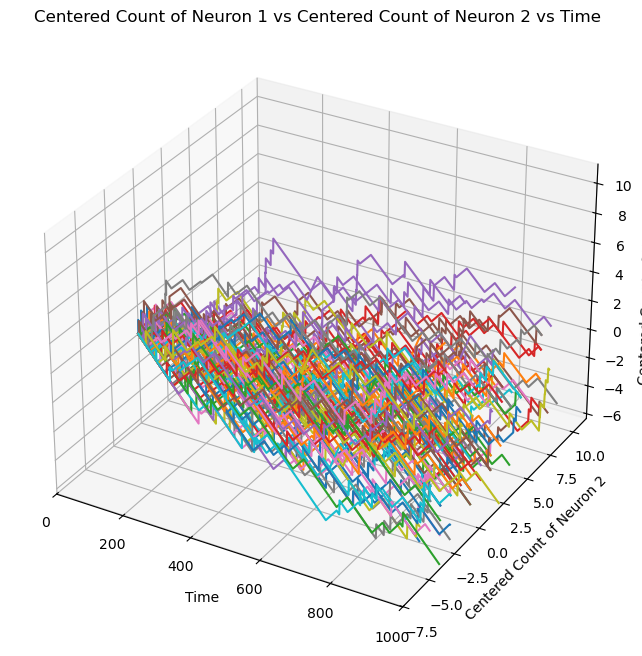

In [24]:
plot_centered_staircase_3d(counting_process_nd_result, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_29796\1282071392.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (counting_process_nd_result[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_29796\1282071392.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (counting_process_nd_result[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_29796\1282071392.py:9: RuntimeWarning: divide by zero encountered in divide
  neuron2_data = (counting_process_nd_result[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


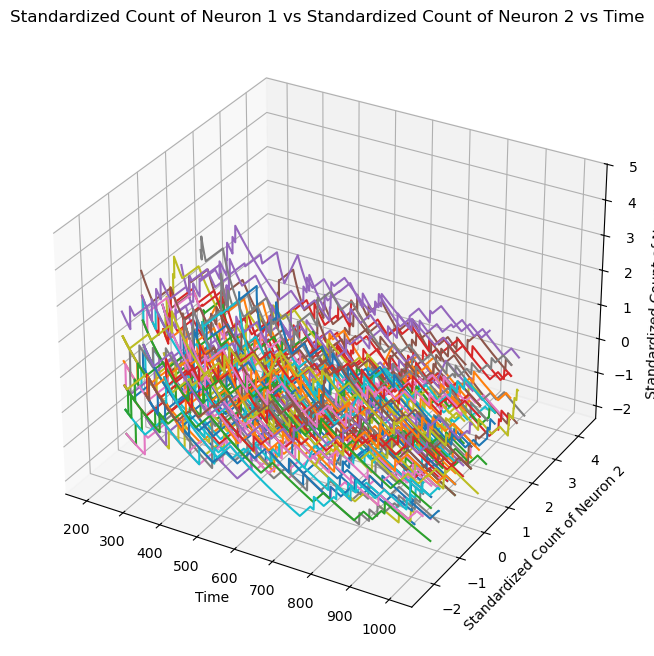

In [25]:
plot_standardized_staircase_3d(counting_process_nd_result, num_samples, theoretical_means, theoretical_std_dev, t0)

In [26]:
plot_centered_and_standardized_staircase_3d(counting_process_nd_result, num_samples, expected_mean)

NameError: name 'expected_mean' is not defined

In [ ]:
plot_count_neuron1_vs_time(counting_process_nd_result, num_samples)

In [ ]:
plot_count_neuron1_vs_neuron2_vs_time(counting_process_nd_result, num_samples)

In [ ]:
# Counting process for two neurons
counting_process_2d = [[0 for _ in range(time)] for _ in range(num_samples)]
for i in range(num_samples):
    count1 = 0
    count2 = 0
    for j in range(time):
        if independent_processes[i][0][j] == 1:
            count1 += 1
        if independent_processes[i][1][j] == 1:
            count2 += 1
        counting_process_2d[i][j] = count1 + count2

plt.figure(figsize=(10,6))
for j in range(num_samples):
    plt.plot([counting_process_2d[j][i] for i in range(time)])
plt.xlabel('Time')
plt.ylabel('Count')
plt.title('Counting Process for Two Neurons')
plt.show()

In [ ]:
# Center staircase minus the expected mean and standardized staircase
mean_spikes_centered = mean_spikes - np.mean(mean_spikes)
standardized_spikes = (mean_spikes - np.mean(mean_spikes)) / np.std(mean_spikes)

In [ ]:
# For plotting
plt.figure()
plt.subplot(211)
plt.title('Mean Spike Counts Centered')
plt.bar(range(num_neurons), mean_spikes_centered)
plt.subplot(212)
plt.title('Standardized Spike Counts')
plt.bar(range(num_neurons), standardized_spikes)
plt.tight_layout()
plt.show()

In [ ]:
# Poisson counting process statistics
print("Poisson Counting Process Statistics:")
print("Mean:", np.mean(n_spikes, axis=1))
print("Covariance:", np.cov(n_spikes))

In [ ]:
# SNN counting process statistics
print("\nSNN Counting Process Statistics:")
print("Mean:", np.mean(snn_spikes, axis=1))
print("Covariance:", np.cov(snn_spikes))

In [ ]:
# Comparison of SNN and Poisson counting process
print("\nComparison of SNN and Poisson Counting Process:")
print("Mean Difference:", np.mean(snn_spikes, axis=1) - np.mean(poisson_spikes, axis=1))
print("Covariance Difference:", np.cov(snn_spikes) - np.cov(poisson_spikes))

In [ ]:
# Standardization SNN counting process statistics
print("\nStandardization SNN Counting Process Statistics:")
standardized_snn_spikes = (snn_spikes - np.mean(snn_spikes, axis=1)[:, np.newaxis]) / np.std(snn_spikes, axis=1)[:, np.newaxis]
print("Mean:", np.mean(standardized_snn_spikes, axis=1))
print("Covariance:", np.cov(standardized_snn_spikes))

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(np.mean(poisson_spikes, axis=1), label='Poisson')
plt.plot(np.mean(snn_spikes, axis=1), label='SNN')
plt.legend()
plt.title('Mean Spike Count')
plt.xlabel('Time')
plt.ylabel('Mean Spike Count')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(np.cov(poisson_spikes)[0, :], label='Poisson')
plt.plot(np.cov(snn_spikes)[0, :], label='SNN')
plt.legend()
plt.title('Covariance of Spike Count')
plt.xlabel('Time')
plt.ylabel('Covariance')
plt.show()

In [ ]:
    # Plot the centered staircase
    for i in range(num_neurons_to_plot):
        axs[0].plot(mean_counting_process[i] - expected_mean)
    axs[0].set_title('Centered Staircase')
    axs[0].set_xlabel('Time')
    axs[0].set_ylabel('Count')

In [ ]:
    # Plot the standardized staircase
    std_counting_process = (mean_counting_process - expected_mean) / np.std(mean_counting_process, axis=1, keepdims=True)
    for i in range(num_neurons_to_plot):
        axs[1].plot(std_counting_process[i])
    axs[1].set_title('Standardized Staircase')
    axs[1].set_xlabel('Time')
    axs[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()